In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (12,6)
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("C:\\Users\\ankit\\Downloads\\uber-raw-data-apr14.csv\\uber-raw-data-apr14.csv", parse_dates=['Date/Time'])
df.head()

,Date/Time,Lat,Lon,Base
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Date/Time    564516 non-null  datetime64[ns]
 1   Lat          564516 non-null  float64       
 2   Lon          564516 non-null  float64       
 3   Base         564516 non-null  object        
 4   hour         564516 non-null  int32         
 5   day_of_week  564516 non-null  int32         
 6   date         564516 non-null  object        
 7   is_weekend   564516 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int32(2), int64(1), object(2)
memory usage: 30.1+ MB


In [6]:
# Extract the hour component from the 'Date/Time' column and create a new 'hour' column in the dataframe
df['hour'] = df['Date/Time'].dt.hour
# Extract day of week 
df['day_of_week'] = df['Date/Time'].dt.dayofweek
# Extract date without time for daily aggragation
df['date'] = df['Date/Time'].dt.date
# Create a binary weekend indicator
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

print("Time feature extrcated:")
print(df[['Date/Time', 'hour', 'day_of_week', 'is_weekend']].head(10))

Time feature extrcated:
            Date/Time  hour  day_of_week  is_weekend
0 2014-04-01 00:11:00     0            1           0
1 2014-04-01 00:17:00     0            1           0
2 2014-04-01 00:21:00     0            1           0
3 2014-04-01 00:28:00     0            1           0
4 2014-04-01 00:33:00     0            1           0
5 2014-04-01 00:33:00     0            1           0
6 2014-04-01 00:39:00     0            1           0
7 2014-04-01 00:45:00     0            1           0
8 2014-04-01 00:55:00     0            1           0
9 2014-04-01 01:01:00     1            1           0


In [8]:
df.head()

,Date/Time,Lat,Lon,Base,hour,day_of_week,date,is_weekend
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,2014-04-01,0
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,2014-04-01,0
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,2014-04-01,0
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,2014-04-01,0
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,2014-04-01,0


**Exploratory Data Analysis**

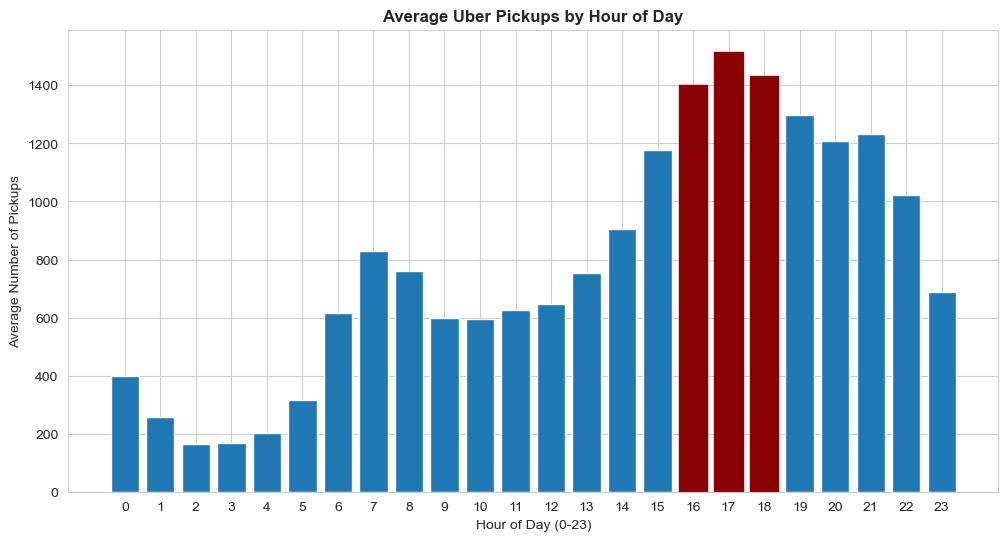

In [14]:
# Aggregate Demand by Hour
hourly_demand = df.groupby('hour').size().reset_index(name='total_pickups')

# Average pickups per hour
num_days = df['date'].nunique()
hourly_demand['avg_pickups'] = hourly_demand['total_pickups'] / num_days

bars = plt.bar(hourly_demand['hour'], hourly_demand['avg_pickups'])

peak_hours = hourly_demand.nlargest(3, 'avg_pickups')['hour'].values
for i, bar in enumerate(bars):
    if i in peak_hours:
        bar.set_color('darkred')

plt.title('Average Uber Pickups by Hour of Day', fontweight='bold')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Number of Pickups')
plt.xticks(range(0,24))
plt.show()

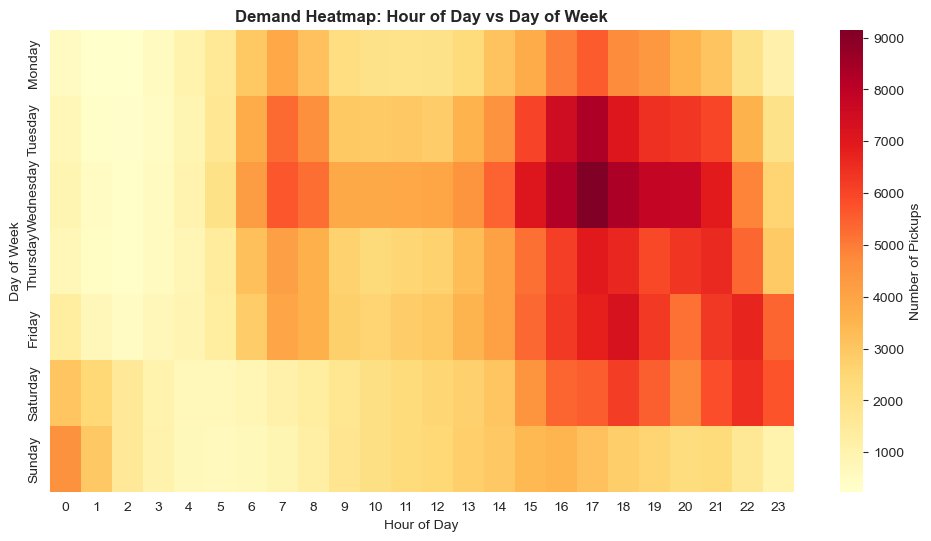

In [18]:
# Create a Hour Day Heatmap

# Create pivot table - Groups data by day of week and hour, counting occurrences
demand_matrix = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
# Normalize by number of weeks to get the average - Calculates total weeks in dataset
num_weeks = len(df) / 7 / 24 / demand_matrix.mean().mean()
# Day names for y axis labels - Defines readable day names for visualization
day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
# Create heatmap - Visualizes demand patterns using color intensity
sns.heatmap(demand_matrix, cmap='YlOrRd', xticklabels=range(24), yticklabels= day_names, cbar_kws={'label':'Number of Pickups'})
plt.title('Demand Heatmap: Hour of Day vs Day of Week', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()